# Utilizing Random Forest to predict the patient's cardiovascular health

## Introduction

In this notebook, the Random Forest algorithm will be utilized to predict if a patient has a cardiovascular health issue.

#### The algorithm

`Random Forest` is an ML algorithm that uses multiple imperfect decision trees voting on the final result to make predictions. The decision trees are created (fit) on the `learning set` with specific arguments chosen by evaluating the `validation set` to have the best accuracy on the final `test set`.

The trees are created in a way to be different, imperfect "experts" on the topic with specific issues, with an expectation that in the final vote, those issues will be less prominent, as other trees should "cover" their imperfections.

## Implementation

First of all, the Random Seed must be defined to always split the dataset in the same way

In [95]:
RANDOM_SEED = 336461617

Now, the `DecisionTree` object will be created. It should, to an extent, be similar to the implementations known from the libraries like scikit-learn (fit function, predict, etc.)

In [ ]:
from typing import Optional, Self
from dataclasses import dataclass
import numpy as np
import numpy.typing as npt
from collections import deque

@dataclass
class Node:
    def __init__(self):
        self.is_leaf: bool = False
        self.prediction: Optional[int] = None
        self.feature: Optional[int] = None
        self.children: dict[int, Self] = {}

class DecisionTree:
    def __init__(self, max_depth: int, num_features: int, min_samples_split: int = 2):
        self.max_depth = max_depth
        self.num_features = num_features
        self.root: Optional[Node] = None
        self.min_samples_split = min_samples_split

    def fit(self, features: npt.NDArray[np.int_], labels: npt.NDArray[np.int_]) -> Self:
        self.root = Node()
        Q: deque[tuple[Node, npt.NDArray[np.int_], npt.NDArray[np.int_], int]] = deque()
        Q.append((self.root, features, labels, 0))

        while Q:
            node, elem_features, elem_labels, depth = Q.popleft()
            node.prediction = self._majority(elem_labels)

            if self._is_pure(elem_labels) or len(elem_labels) < self.min_samples_split or depth >= self.max_depth:
                node.is_leaf = True
                continue

            feature_subset = self._random_features(elem_features.shape[1])
            best_feature = self._best_feature(elem_features, elem_labels, feature_subset)
            node.feature = best_feature
            feature_options = np.unique(elem_features[:, best_feature])

            for feature in feature_options:
                mask = elem_features[:, best_feature] == feature
                features_child, labels_child = elem_features[mask], elem_labels[mask]

                if labels_child.size == 0:
                    continue

                child = Node()
                node.children[feature] = child
                Q.append((child, features_child, labels_child, depth + 1))

        return self

    def predict(self, data_points: npt.NDArray[np.int_]) -> npt.NDArray[np.int_]:
        return np.array([self._predict_one(dp) for dp in data_points])

    def _random_features(self, n_features: int) -> npt.NDArray[np.int_]:
        return np.random.choice(n_features, self.num_features, replace=False)

    def _majority(self, labels: npt.NDArray[np.int_]) -> int:
        return int(np.bincount(labels).argmax())

    def _is_pure(self, labels: npt.NDArray[np.int_]) -> bool:
        return np.unique(labels).size == 1

    def _entropy(self, labels: npt.NDArray[np.int_]) -> float:
        counts = np.bincount(labels)
        probabilities = counts[counts > 0] / labels.size
        return float(-np.sum(probabilities * np.log2(probabilities)))

    def _best_feature(self, features: npt.NDArray[np.int_], labels: npt.NDArray[np.int_], feature_subset: npt.NDArray[np.int_]) -> int:
        information_gains = [self._information_gain(features, labels, feature) for feature in feature_subset]
        best_index = int(np.argmax(information_gains))
        return int(feature_subset[best_index])

    def _information_gain(self, features: npt.NDArray[np.int_], labels: npt.NDArray[np.int_], feature_index: int) -> float:
        parent_entropy = self._entropy(labels)
        feature_values = np.unique(features[:, feature_index])
        weighted_entropy = 0.0

        for value in feature_values:
            mask = features[:, feature_index] == value
            labels_subset = labels[mask]

            if labels_subset.size == 0:
                continue

            weight = labels_subset.size / labels.size
            weighted_entropy += weight * self._entropy(labels_subset)

        return parent_entropy - weighted_entropy

    def _predict_one(self, data_point: npt.NDArray[np.int_]) -> int:
        node = self.root

        while node is not None and not node.is_leaf:
            if node.feature is None:
                assert node.prediction is not None
                return node.prediction
            feature_value = int(data_point[node.feature])

            if feature_value not in node.children:
                assert node.prediction is not None
                return node.prediction

            node = node.children[feature_value]

        assert node is not None
        assert node.prediction is not None
        return node.prediction


The next step is to create the whole `RandomForest` class that would represent the whole forest, with a given amount of `DecisionTrees`

In [ ]:
from typing import cast
from tqdm.notebook import tqdm

class RandomForest:
    def __init__(self, n_trees: int, max_depth: int, num_features: int, min_samples_split: int = 2):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.num_features = num_features
        self.trees: list[DecisionTree] = []
        self.min_samples_split = min_samples_split

    def fit(self, features: npt.NDArray[np.int_], labels: npt.NDArray[np.int_], use_tqdm: bool = True) -> Self:
        self.trees = []
        n_samples = features.shape[0]

        for _ in (tqdm(range(self.n_trees), desc="Creating the RandomForest") if use_tqdm else range(self.n_trees)):
            indices: npt.NDArray[np.int_] = cast(npt.NDArray[np.int_], np.random.choice(
                n_samples,
                size=n_samples,
                replace=True
            ))

            bootstrap_features = features[indices]
            bootstrap_labels = labels[indices]

            tree = DecisionTree(
                max_depth=self.max_depth,
                num_features=self.num_features,
                min_samples_split=self.min_samples_split
            )

            self.trees.append(tree.fit(bootstrap_features, bootstrap_labels))

        return self

    def predict(self, features: npt.NDArray[np.int_], use_tqdm: bool = True) -> npt.NDArray[np.int_]:
        tree_predictions = np.array(
            [tree.predict(features) for tree in (tqdm(self.trees, desc="Running the RandomForest predictions") if use_tqdm else self.trees)]
        )

        tree_predictions = np.asarray(tree_predictions)

        return np.array([
            self._majority_vote(tree_predictions[:, i])
            for i in range(tree_predictions.shape[1])
        ])

    def _majority_vote(self, predictions: npt.NDArray[np.int_]) -> int:
        return int(np.bincount(predictions).argmax())


The data is taken from the [kagglehub page](https://www.kaggle.com/datasets/bhadaneeraj/cardio-vascular-disease-detection), we have to read it first

In [98]:
import kagglehub
from pathlib import Path

path = Path(kagglehub.dataset_download("bhadaneeraj/cardio-vascular-disease-detection"))
print(path)

/Users/pitkwiecien/.cache/kagglehub/datasets/bhadaneeraj/cardio-vascular-disease-detection/versions/1


Now the data will be processed in a specific way to fit the `RandomForest` implementation. This involves preparing the data and making it descreet by fitting it into specific buckets.

In [99]:
import pandas as pd
from sklearn.model_selection import train_test_split


def load_dataset(dir_path: Path, file_path: Path | str, seperator: str = ";"):
    return pd.read_csv(dir_path / file_path, sep=seperator)


def preprocess_cardio_dataset(df: pd.DataFrame) -> tuple[npt.NDArray[np.int_], npt.NDArray[np.int_]]:
    df = df.drop(columns=["id"], errors="ignore")

    labels = df["cardio"].to_numpy(dtype=np.int_)
    features = df.drop(columns=["cardio"]).to_numpy(dtype=np.float64)

    age = features[:, 0]
    age_bins = np.array([10, 20, 30, 50, 60, 80]) * 365
    features[:, 0] = np.digitize(age, age_bins)

    height = features[:, 2]
    height_bins = [160, 170, 180, 190]
    features[:, 2] = np.digitize(height, height_bins)

    weight = features[:, 3]
    weight_bins = [60, 75, 90, 110]
    features[:, 3] = np.digitize(weight, weight_bins)

    ap_hi = features[:, 4]
    ap_hi_bins = [120, 140, 160, 180, 200]
    features[:, 4] = np.digitize(ap_hi, ap_hi_bins)

    ap_lo = features[:, 5]
    ap_lo_bins = [80, 90, 100, 110]
    features[:, 5] = np.digitize(ap_lo, ap_lo_bins)

    features = features.astype(np.int_)
    return features, labels


def split_dataset(features: npt.NDArray[np.int_], labels: npt.NDArray[np.int_], test_size: float = 0.3)-> tuple[npt.NDArray[np.int_], npt.NDArray[np.int_], npt.NDArray[np.int_], npt.NDArray[np.int_], npt.NDArray[np.int_],npt.NDArray[np.int_]]:
    features_train, features_temp, labels_train, labels_temp = cast(
        tuple[npt.NDArray[np.int_], npt.NDArray[np.int_], npt.NDArray[np.int_], npt.NDArray[np.int_]],
        train_test_split(
            features,
            labels,
            test_size=test_size,
            random_state=RANDOM_SEED,
            stratify=labels
        )
    )

    features_val, features_test, labels_val, labels_test = cast(
        tuple[npt.NDArray[np.int_], npt.NDArray[np.int_], npt.NDArray[np.int_], npt.NDArray[np.int_]],
        train_test_split(
            features_temp,
            labels_temp,
            test_size=0.5,
            random_state=RANDOM_SEED,
            stratify=labels_temp
        )
    )

    return (
        features_train,
        features_val,
        features_test,
        labels_train,
        labels_val,
        labels_test
    )


def prepare_cardio_data(dir_path: Path, file_path: Path | str, test_size: float = 0.3):
    df = load_dataset(dir_path, file_path)
    features, labels = preprocess_cardio_dataset(df)
    return split_dataset(features, labels, test_size)



Now the main testing functions will be defined to run the simulation easily and to compare the results with the `RandomForestClassifier` object from the `scikit-learn` library. The function to visualize the confusion matrix will be implemented as well.

The most important output evaluation parameters are as follows:
- `accuracy` - how many evaluations matched the expected outcome
- `precision` – how many predicted positive cases were actually correct
- `recall` – how many actual positive cases were correctly identified
- `f1` – a balanced measure combining precision and recall into a single score

The previously mentioned `confusion_matrix` will be displayed as well, which illustrates more precisely, how many evaluations matched which expected results

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

@dataclass
class TestResult:
    accuracy: float
    f1: float
    precision: float
    recall: float
    confusion_matrix: npt.NDArray[np.float64]

    def __str__(self) -> str:
        return self.to_string()

    def to_string(self, comparison: bool = False) -> str:
        suffix = " %" if comparison else ""
        string = (
            f"Accuracy: {self.accuracy}{suffix}"
            f"\nF1: {self.f1}{suffix}"
            f"\nPrecision: {self.precision}{suffix}"
            f"\nRecall: {self.recall}{suffix}"
            + (f"\nConfusion Matrix: \n{self.confusion_matrix}" if not comparison else "")
        )
        return string

    def compare_to(self, other: Self):
        return TestResult(
            self.accuracy / other.accuracy * 100,
            self.f1 / other.f1 * 100,
            self.precision / other.precision * 100,
            self.recall / other.recall * 100,
            np.array([])
        )


def perform_test(n_trees: int, max_depth: int, num_features: int, use_test: bool = False, test_size: float = 0.3, compare_to_builtin: bool = False, use_tqdm: bool = True, min_samples_split: int = 2) -> TestResult:
    features_train, features_val, features_test, labels_train, labels_val, labels_test = prepare_cardio_data(path, "cardio_train.csv", test_size)

    rf = RandomForest(
        n_trees=n_trees,
        max_depth=max_depth,
        num_features=num_features,
        min_samples_split=min_samples_split
    ) if not compare_to_builtin else RandomForestClassifier(
        n_estimators=n_trees,
        max_depth=max_depth,
        random_state=RANDOM_SEED,
        min_samples_split=min_samples_split,
        n_jobs=-1
    )

    features = features_val if not use_test else features_test
    labels = labels_val if not use_test else labels_test

    if compare_to_builtin:
        assert isinstance(rf, RandomForestClassifier)
        rf.fit(features_train, labels_train)
        labels_pred = rf.predict(features)
    else:
        assert isinstance(rf, RandomForest)
        rf.fit(features_train, labels_train, use_tqdm)
        labels_pred = rf.predict(features, use_tqdm)

    return TestResult(
        float(accuracy_score(labels, labels_pred)),
        float(f1_score(labels, labels_pred)),
        float(precision_score(labels, labels_pred)),
        float(recall_score(labels, labels_pred)),
        confusion_matrix(labels, labels_pred)
    )


def plot_confusion_matrix(result: TestResult, title: str = "Confusion Matrix") -> None:
    cm = result.confusion_matrix

    cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100
    labels = np.array([
        [f"{count}\n({pct:.1f}%)" for count, pct in zip(row_c, row_p)]
        for row_c, row_p in zip(cm, cm_percent)
    ])

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=labels,
        fmt="",
        cmap="Blues",
        xticklabels=["Healthy (0)", "Sick (1)"],
        yticklabels=["Healthy (0)", "Sick (1)"],
        linewidths=0.5,
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("Expected Result")
    ax.set_ylabel("Actual Result")
    plt.tight_layout()
    plt.show()


def test(n_trees: int,
         max_depth: int,
         num_features: int,
         use_test: bool = False,
         test_size: float = 0.3,
         compare_to_builtin: bool = True,
         min_samples_split: int = 2,
         plot_matrix: bool = True
         ) -> None:
    test_result = perform_test(n_trees, max_depth, num_features, use_test, test_size, min_samples_split=min_samples_split)
    print("Result:")
    print(test_result)
    print()

    if compare_to_builtin:
        builtin_test_result = perform_test(n_trees, max_depth, num_features, use_test, test_size, True)
        print("Builtin result: ")
        print(builtin_test_result)
        print()
        comparison_result = test_result.compare_to(builtin_test_result)
        print("Comparison:")
        print(comparison_result.to_string(True))

    if plot_matrix:
        plot_confusion_matrix(test_result, "Confusion Matrix")

## Parameter selection

Firstly, the `test` function will be run to ensure that the `RandomForest` does create predictions that are at least more accurate than random guessing. The result is thrilling - the custom `RandomForest` implementation performed even better than the one in the `scikit-learn` library in most of the cases

Creating the RandomForest:   0%|          | 0/10 [00:00<?, ?it/s]

Running the RandomForest predictions:   0%|          | 0/10 [00:00<?, ?it/s]

Result:
Accuracy: 0.726984126984127
F1: 0.7024533445166702
Precision: 0.7710011507479861
Recall: 0.6450991719622569
Confusion Matrix: 
[[4207  995]
 [1843 3350]]

Builtin result: 
Accuracy: 0.7228475228475228
F1: 0.692102169498771
Precision: 0.7776176753121998
Recall: 0.6235316772578471
Confusion Matrix: 
[[4276  926]
 [1955 3238]]

Comparison:
Accuracy: 100.57226510513708 %
F1: 101.49561372208898 %
Precision: 99.14912883615239 %
Recall: 103.45892526250773 %


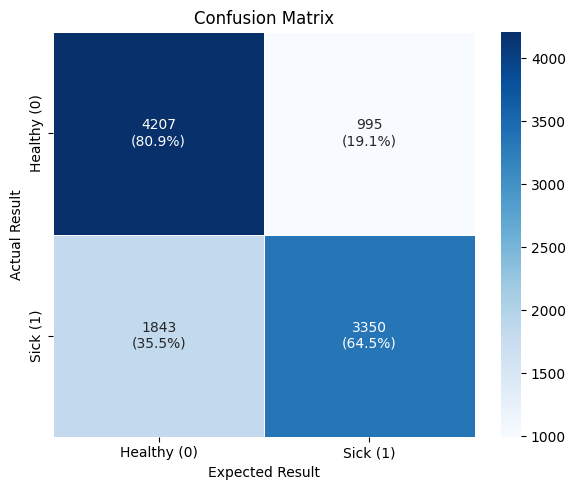

In [125]:
test(
    n_trees=10,
    max_depth=5,
    num_features=4
)

To evaluate and visualize a bigger amount of evaluations with different evaluations, the `grid_test` method will be defined, which will allow us to see, which parameters are the most optimal for our dataset. We will be able to plot all of these results on a 3D graph using the `plot_surfaces` function (4 graphs for 4 main evaluated parameters)

In [122]:
from collections.abc import Iterable, Sequence
from typing import TypeVar

T = TypeVar("T")

IntParam = int | Iterable[int]
FloatParam = float | Iterable[float]


def _is_iterable(value: object) -> bool:
    return isinstance(value, Iterable) and not isinstance(value, (str, bytes))


def _ensure_iterable(value: T | Iterable[T]) -> Iterable[T]:
    return value if _is_iterable(value) else [value]


@dataclass(slots=True)
class GridResult:
    n_trees: int
    max_depth: int
    num_features: int
    test_size: float
    accuracy: float
    f1: float
    precision: float
    recall: float


def grid_test(
    n_trees: IntParam,
    max_depth: IntParam,
    num_features: IntParam,
    test_size: FloatParam,
    use_test: bool = False
) -> list[GridResult]:

    params = {
        "n_trees": n_trees,
        "max_depth": max_depth,
        "num_features": num_features,
        "test_size": test_size,
    }

    if sum(_is_iterable(v) for v in params.values()) != 2:
        raise ValueError("Exactly two parameters must be iterables")

    iterables = {
        k: _ensure_iterable(v)
        for k, v in params.items()
    }

    scalars = {
        k: (next(iter(v)) if _is_iterable(v) else v)
        for k, v in params.items()
    }

    iterable_keys = [k for k, v in params.items() if _is_iterable(v)]

    outer_key, inner_key = iterable_keys

    results: list[GridResult] = []

    for outer_val in tqdm(iterables[outer_key], desc=outer_key):
        for inner_val in tqdm(iterables[inner_key], desc=inner_key, leave=False):

            current = dict(scalars)
            current[outer_key] = outer_val
            current[inner_key] = inner_val

            res = perform_test(
                current["n_trees"],
                current["max_depth"],
                current["num_features"],
                use_test,
                current["test_size"],
                False,
                False
            )

            results.append(
                GridResult(
                    n_trees=current["n_trees"],
                    max_depth=current["max_depth"],
                    num_features=current["num_features"],
                    test_size=current["test_size"],
                    accuracy=res.accuracy,
                    f1=res.f1,
                    precision=res.precision,
                    recall=res.recall,
                )
            )

    return results


def plot_surfaces(
    results: Sequence[GridResult],
    x_param: str,
    y_param: str,
) -> None:
    x_values = np.array([getattr(r, x_param) for r in results])
    y_values = np.array([getattr(r, y_param) for r in results])
    accuracy = np.array([r.accuracy for r in results])
    f1 = np.array([r.f1 for r in results])
    precision = np.array([r.precision for r in results])
    recall = np.array([r.recall for r in results])

    x_unique = np.unique(x_values)
    y_unique = np.unique(y_values)

    X, Y = np.meshgrid(x_unique, y_unique, indexing="ij")
    Z_acc = np.full(X.shape, np.nan)
    Z_f1 = np.full(X.shape, np.nan)
    Z_prec = np.full(X.shape, np.nan)
    Z_rec = np.full(X.shape, np.nan)

    x_idx = {v: i for i, v in enumerate(x_unique)}
    y_idx = {v: i for i, v in enumerate(y_unique)}

    for r, acc, f1_val, prec_val, rec_val in zip(results, accuracy, f1, precision, recall):
        xi = x_idx[getattr(r, x_param)]
        yi = y_idx[getattr(r, y_param)]
        Z_acc[xi, yi] = acc
        Z_f1[xi, yi] = f1_val
        Z_prec[xi, yi] = prec_val
        Z_rec[xi, yi] = rec_val

    metrics = [
        (Z_acc, accuracy, "Accuracy"),
        (Z_f1, f1, "F1 Score"),
        (Z_prec, precision, "Precision"),
        (Z_rec, recall, "Recall"),
    ]

    fig = plt.figure(figsize=(14, 12))

    for idx, (Z, values, title) in enumerate(metrics, start=1):
        ax = fig.add_subplot(2, 2, idx, projection="3d")
        surf = ax.plot_surface(X, Y, Z, alpha=0.7, cmap="viridis")
        ax.scatter(x_values, y_values, values, color="red", s=40, zorder=5, label="data points")
        ax.set_title(title)
        ax.set_xlabel(x_param)
        ax.set_ylabel(y_param)
        ax.set_zlabel(title)
        ax.legend()
        fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

    plt.tight_layout()
    plt.show()


def get_best_result(results: Sequence[GridResult]) -> GridResult:
    return max(results, key=lambda r: r.accuracy)

Finally, the `run_grid_test` function will be created to combine the grid evaluation and graphing functionalities to make running the simlations easy and convenient

In [123]:
def run_grid_test(
    n_trees: IntParam,
    max_depth: IntParam,
    num_features: IntParam,
    test_size: FloatParam,
    use_test: bool = False
) -> GridResult:
    results = grid_test(
        n_trees=n_trees,
        max_depth=max_depth,
        num_features=num_features,
        test_size=test_size,
        use_test=use_test
    )

    params: dict[str, IntParam | FloatParam] = {
        "n_trees": n_trees,
        "max_depth": max_depth,
        "num_features": num_features,
        "test_size": test_size,
    }
    iterable_keys = [k for k, v in params.items() if _is_iterable(v)]
    x_param, y_param = iterable_keys
    plot_surfaces(results, x_param=x_param, y_param=y_param)

    best = get_best_result(results)
    best_test_result = perform_test(
        best.n_trees,
        best.max_depth,
        best.num_features,
        use_test,
        best.test_size,
        False,
        False
    )
    plot_confusion_matrix(best_test_result, "Confusion Matrix - best result")

    return best

The first simulation visualizes, how n_trees and max_depth effect the evaluation parameters, as they are the 2 most important parameters we have access to.

The result shows us that 50 trees and a depth of 7 showed the best accuracy. Higher depths probably led to a bit of overfitting, that's why they performed a bit worse. A bigger amount of trees did not have a major negative effect on the experiment, but they did not improve the final result at all, making them redundant and making the `RandomForest` unnecessarily big.

n_trees:   0%|          | 0/10 [00:00<?, ?it/s]

max_depth:   0%|          | 0/9 [00:00<?, ?it/s]

max_depth:   0%|          | 0/9 [00:00<?, ?it/s]

max_depth:   0%|          | 0/9 [00:00<?, ?it/s]

max_depth:   0%|          | 0/9 [00:00<?, ?it/s]

...

max_depth:   0%|          | 0/9 [00:00<?, ?it/s]

max_depth:   0%|          | 0/9 [00:00<?, ?it/s]

max_depth:   0%|          | 0/9 [00:00<?, ?it/s]

max_depth:   0%|          | 0/9 [00:00<?, ?it/s]

max_depth:   0%|          | 0/9 [00:00<?, ?it/s]

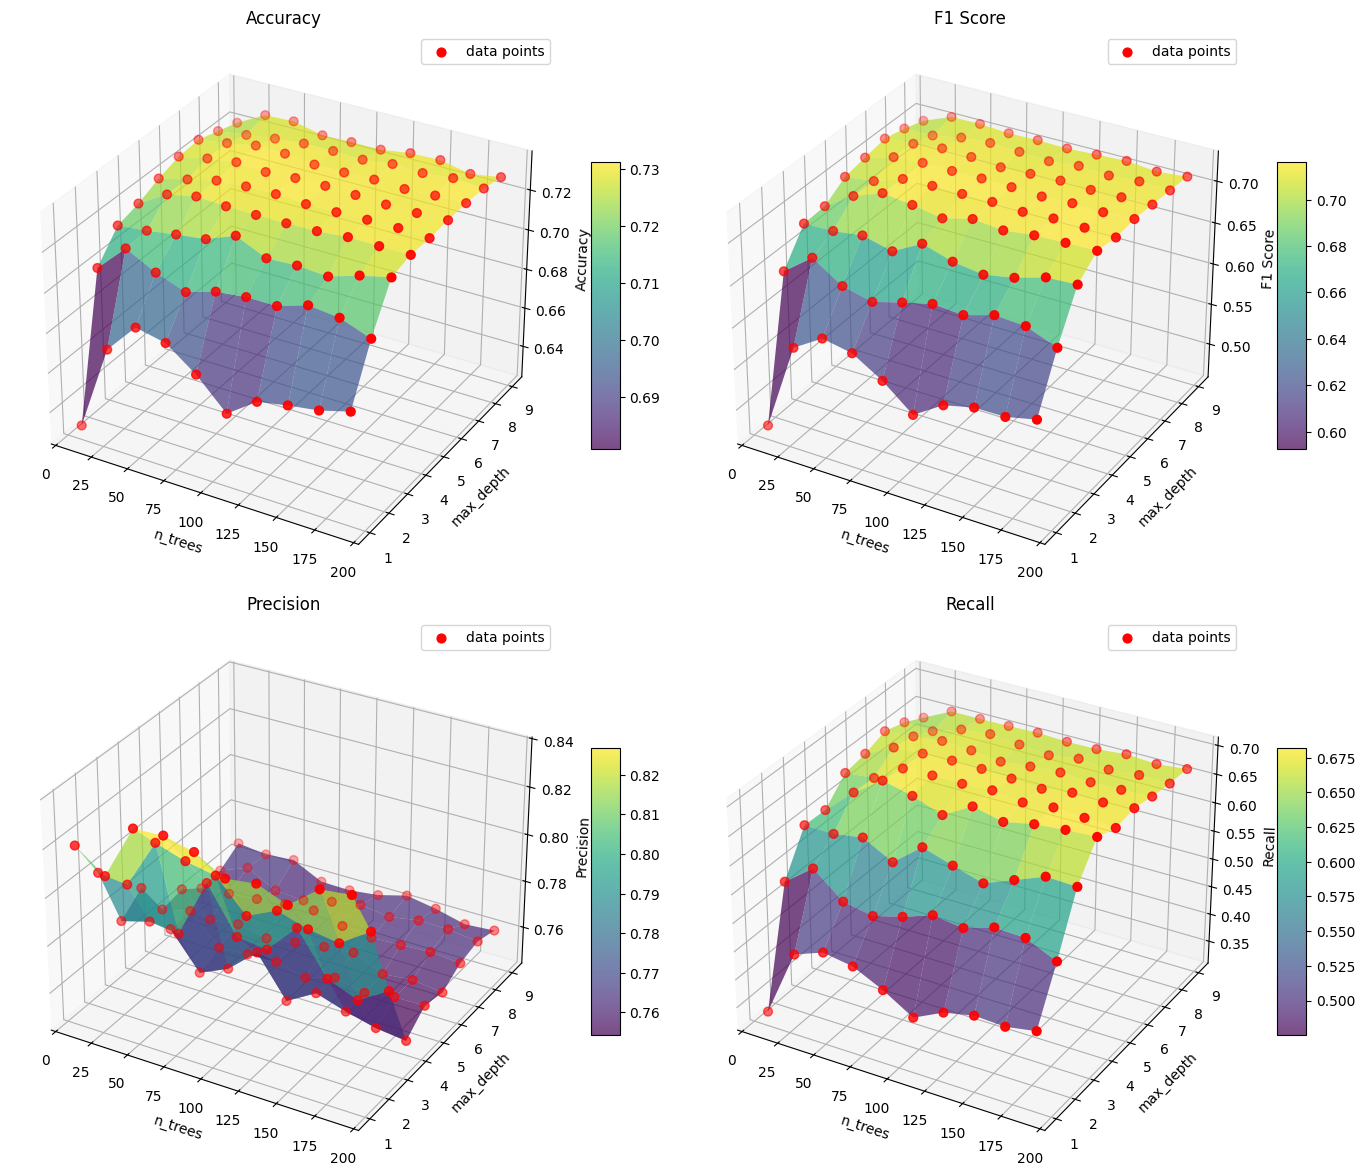

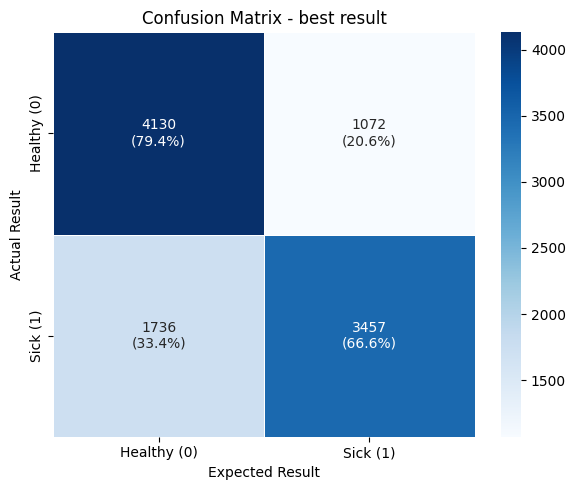

GridResult(n_trees=50, max_depth=7, num_features=3, test_size=0.3, accuracy=0.7318903318903319, f1=0.7147681915873503, precision=0.762778505897772, recall=0.6724436741767764)

In [124]:
run_grid_test(
    n_trees=range(10, 201, 20),
    max_depth=range(1, 10, 1),
    num_features=3,
    test_size=.3
)

Now the inpact of the 2 other parameters was analyzed - `num_features` and `test_size`. The other 2 parameters were the ones deemed most optimal by the previous experiment.

The result was, as expected, `num_features` of 3 and `test_size` of .2, as lower `num_features` were too random and higher ones probably made the trees too similar.

num_features:   0%|          | 0/9 [00:00<?, ?it/s]

test_size:   0%|          | 0/9 [00:00<?, ?it/s]

test_size:   0%|          | 0/9 [00:00<?, ?it/s]

test_size:   0%|          | 0/9 [00:00<?, ?it/s]

test_size:   0%|          | 0/9 [00:00<?, ?it/s]

test_size:   0%|          | 0/9 [00:00<?, ?it/s]

test_size:   0%|          | 0/9 [00:00<?, ?it/s]

test_size:   0%|          | 0/9 [00:00<?, ?it/s]

test_size:   0%|          | 0/9 [00:00<?, ?it/s]

test_size:   0%|          | 0/9 [00:00<?, ?it/s]

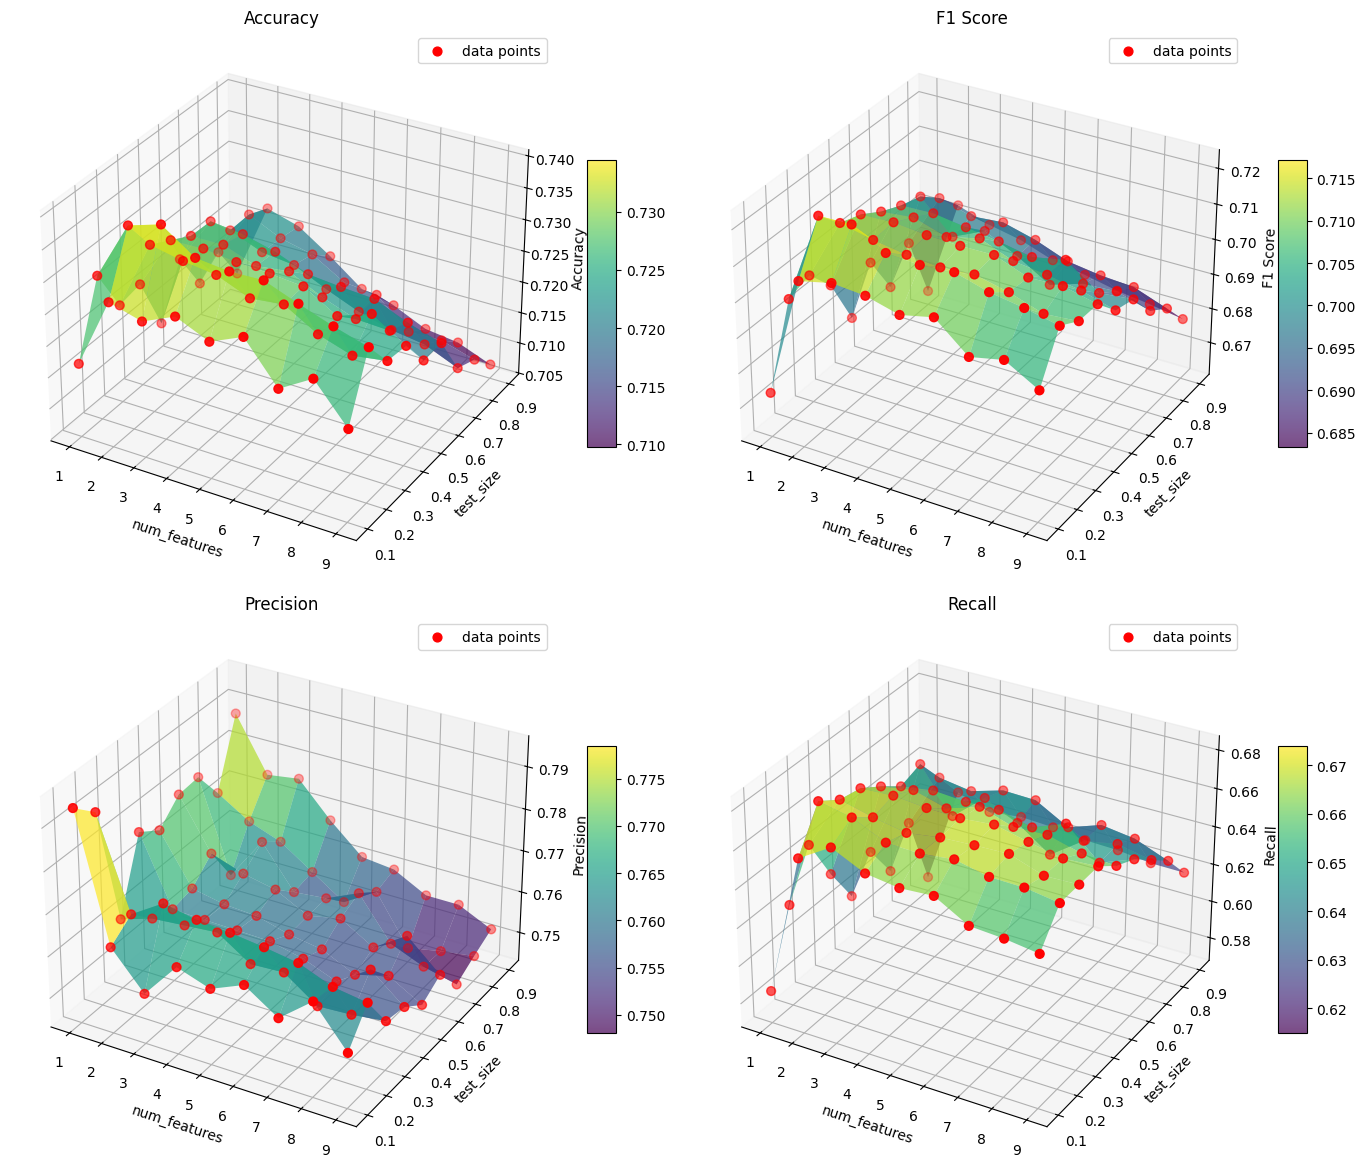

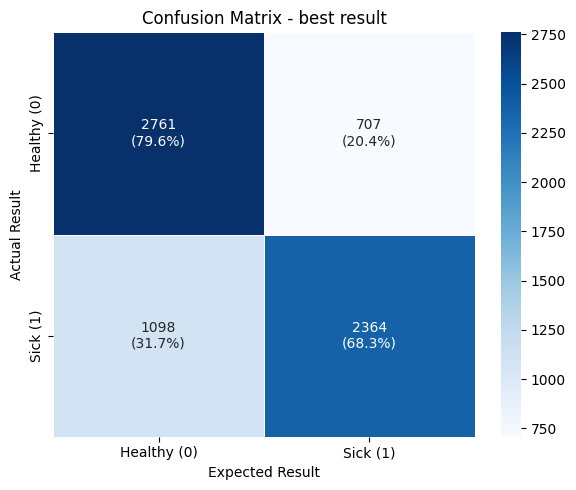

GridResult(n_trees=50, max_depth=7, num_features=3, test_size=np.float64(0.2), accuracy=0.7386724386724387, f1=0.7210842445710766, precision=0.7723523589574398, recall=0.6761987290583478)

In [126]:
run_grid_test(
    n_trees=50,
    max_depth=7,
    num_features=range(1, 10),
    test_size=np.arange(0.1, 0.91, 0.1)
)

## Testing

Finally, the final `test` will be ran, now on the `test set` of data, not on `validation set`. It will show, how well do the found parameters perform on a different data set. The final parameters were:
- `n_trees` = 50
- `max_depth` = 7
- `num_features` = 3
- `test_size` = 0.2

The final result is just slightly worse than the validation set. This is not worrying, as the difference is very small. It still performed mostly better than the `scikit-learn` version.

Creating the RandomForest:   0%|          | 0/50 [00:00<?, ?it/s]

Running the RandomForest predictions:   0%|          | 0/50 [00:00<?, ?it/s]

Result:
Accuracy: 0.7221180204876642
F1: 0.7055045871559633
Precision: 0.7497562560935976
Recall: 0.666185388391568
Confusion Matrix: 
[[2698  770]
 [1156 2307]]

Builtin result: 
Accuracy: 0.7216851825133458
F1: 0.6905182095299214
Precision: 0.7768953068592058
Recall: 0.6214265088073925
Confusion Matrix: 
[[2850  618]
 [1311 2152]]

Comparison:
Accuracy: 100.05997600959617 %
F1: 102.17030882302787 %
Precision: 96.50672998974281 %
Recall: 107.20260223048328 %


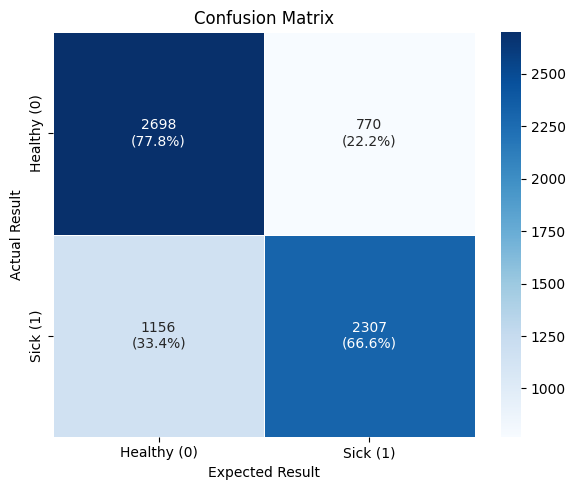

In [128]:
test(
    n_trees=50,
    max_depth=7,
    num_features=3,
    test_size=0.2,
    use_test=True
)